# 0.0. IMPORTS

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as m
import seaborn as sns
import scipy
import warnings
import sweetviz as sv
from scipy.stats import boxcox
#Imports para analise e modelagem de series temporais
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
warnings.filterwarnings( 'ignore' )

/home/felipe/anaconda3/envs/ts_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/felipe/anaconda3/envs/ts_env/lib/python3.10/site-packages/sweetviz/graph.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


## 0.1. Helper Functions

In [2]:
# Function to test stationarity
def test_stationarity(series, window = 12, title = 'Rolling Statistics and Dickey-Fuller Test'):
    
    # 1. Calculate rolling statistics
    rolmean = series.rolling(window = window).mean()
    rolstd = series.rolling(window = window).std()
    
    # 2. Plot rolling statistics
    plt.figure(figsize = (14, 6))
    plt.plot(series, color = 'blue', label = 'Original')
    plt.plot(rolmean, color = 'red', label = 'Rolling Mean')
    plt.plot(rolstd, color = 'black', label = 'Rolling Standard Deviation')
    plt.legend(loc = 'best')
    plt.title(title)
    plt.show(block = False)
    
    # 3. Dickey-Fuller Test
    print('\nResults of Dickey-Fuller Test:')
    dftest = adfuller(series, autolag = 'AIC')
    dfoutput = pd.Series(dftest[0:4], index = ['Test Statistic',
                                               'p-value',
                                               'Number of Lags Used',
                                               'Number of Observations Used'])
    
    for key, value in dftest[4].items():
        dfoutput['Critical Value (%s)' %key] = value
        
    print(dfoutput)
    
    # 4. Conclusion based on p-value
    if dfoutput['p-value'] > 0.05:
        print('\nConclusion:\nThe p-value is greater than 0.05; therefore, we fail to reject the null hypothesis. The series is likely non-stationary.')
    else:
        print('\nConclusion:\nThe p-value is less than 0.05; therefore, we have evidence to reject the null hypothesis. This series is likely stationary.\n')

In [114]:
#funcao para differenciacao
def diffFunc(dataset, interval=1):
    # Verifica se a entrada é um Pandas Series ou DataFrame
    if isinstance(dataset, (pd.Series, pd.DataFrame)):
        return dataset.diff(periods=interval).dropna()
    else:
        # Mantém a lógica de lista como fallback, mas converte para Series no retorno
        diff = list()
        for i in range(interval, len(dataset)):
            value = dataset[i] - dataset[i - interval]
            diff.append(value)
        return pd.Series(diff, name="diffed_data")

## 0.2. Loading data

In [3]:
data = pd.read_csv('../datasets/Foodshop.csv')

# 1.0. (STEP 1) DATA DESCRIPTION

In [4]:
df1 = data.copy()

## 1.1. Rename Columns

In [5]:
#No need to rename columns
df1.columns

Index(['date', 'consumption_mwh_day', 'temp_mean_c', 'is_holiday'], dtype='object')

## 1.2. Data Dimensions

In [6]:
print('Number of Rows: {}'.format(df1.shape[0]))
print('Number of Cols: {}'.format(df1.shape[1]))

Number of Rows: 9549
Number of Cols: 4


## 1.3. Data Types

In [7]:
df1.dtypes

date                    object
consumption_mwh_day    float64
temp_mean_c            float64
is_holiday               int64
dtype: object

In [8]:
df1['date'] = pd.to_datetime(df1['date'])

## 1.4. Check NA

In [9]:
df1.isna().sum()

date                     0
consumption_mwh_day      4
temp_mean_c            113
is_holiday               0
dtype: int64

## 1.5. Fillout NA

In [10]:
# Adding info about year and month to the dataset
df1['year'] = df1['date'].dt.year
df1['month'] = df1['date'].dt.month

In [11]:
# consumption_mwh_day  NAs, will be filled with the monthly mean of the respective year
df1_temp = df1[df1['consumption_mwh_day'].isna()== True]
df1_temp

,date,consumption_mwh_day,temp_mean_c,is_holiday,year,month
5083,2013-12-01,NaN,21.0,0,2013,12
5145,2014-02-01,NaN,27.2,0,2014,2
5577,2015-04-09,NaN,19.3,0,2015,4
9548,2026-02-21,NaN,NaN,0,2026,2


In [12]:
df1['consumption_mwh_day']= df1['consumption_mwh_day'].fillna(df1.groupby(['year','month'])['consumption_mwh_day'].transform('mean'))

In [13]:
df1.iloc[4780]

date                   2013-02-01 00:00:00
consumption_mwh_day             444.393631
temp_mean_c                           23.2
is_holiday                               0
year                                  2013
month                                    2
Name: 4780, dtype: object

In [14]:
df1.iloc[5212]

date                   2014-04-09 00:00:00
consumption_mwh_day             479.517112
temp_mean_c                           24.8
is_holiday                               0
year                                  2014
month                                    4
Name: 5212, dtype: object

In [15]:
# temp_mean_c  NAs, will be filled with the monthly mean of the respective year
df1_temp = df1[df1['temp_mean_c'].isna()== True]
df1_temp.head()

,date,consumption_mwh_day,temp_mean_c,is_holiday,year,month
51,2000-02-21,303.68105,NaN,0,2000,2
58,2000-02-28,324.46105,NaN,0,2000,2
96,2000-04-06,319.22475,NaN,0,2000,4
103,2000-04-13,333.03655,NaN,0,2000,4
104,2000-04-14,334.47080,NaN,0,2000,4


In [16]:

df1['temp_mean_c'] = df1['temp_mean_c'].fillna(df1.groupby(['year','month'])['temp_mean_c'].transform('mean'))

In [17]:
df1.iloc[51]

date                   2000-02-21 00:00:00
consumption_mwh_day              303.68105
temp_mean_c                           22.6
is_holiday                               0
year                                  2000
month                                    2
Name: 51, dtype: object

In [18]:
df1.iloc[96]

date                   2000-04-06 00:00:00
consumption_mwh_day              319.22475
temp_mean_c                      21.166667
is_holiday                               0
year                                  2000
month                                    4
Name: 96, dtype: object

In [19]:
# CHecking if all NAs were filled out
df1.isna().sum()

date                   0
consumption_mwh_day    0
temp_mean_c            0
is_holiday             0
year                   0
month                  0
dtype: int64

## 1.6. Change Types

In [20]:
df1.dtypes

date                   datetime64[ns]
consumption_mwh_day           float64
temp_mean_c                   float64
is_holiday                      int64
year                            int32
month                           int32
dtype: object

In [21]:
df1['is_holiday'] = df1['is_holiday'].astype('bool')

## 1.7. Descriptive Statistical

### 1.7.1 Numerical Attributes

In [22]:
num_attributes = df1.select_dtypes(include=['float64'])

In [23]:
#Central Tendency - mean, median

ct1 = pd.DataFrame(num_attributes.apply(np.mean)).T
ct2 = pd.DataFrame(num_attributes.apply(np.median)).T

# Dispersion - std, min, max, range, skew, kurtosis
d1 = pd.DataFrame(num_attributes.apply(np.std)).T
d2 = pd.DataFrame(num_attributes.apply(min)).T
d3 = pd.DataFrame(num_attributes.apply(max)).T
d4 = pd.DataFrame(num_attributes.apply(lambda x: x.max() - x.min())).T
d5 = pd.DataFrame(num_attributes.apply(lambda x: x.skew())).T
d6 = pd.DataFrame(num_attributes.apply(lambda x: x.kurtosis())).T

#concatenate
m = pd.concat([d2,d3,d4,ct1,ct2,d1,d5,d6]).T.reset_index()
m.columns = ['attribute','min','max','range','mean','median','std','skew','kurtosis']
m

,attribute,min,max,range,mean,median,std,skew,kurtosis
0,consumption_mwh_day,190.54063,667.01876,476.47813,406.760037,406.666325,78.411485,0.184981,-0.247815
1,temp_mean_c,7.10000,29.50000,22.40000,20.248256,20.500000,3.422695,-0.304939,-0.214175


In [24]:
#    - Skewness: Measures the asymmetry. 
#      (Skew > 0: Right tail; Skew < 0: Left tail; Skew ~ 0: Symmetric).
#    - Kurtosis: Measures the "peakedness" and presence of outliers.
#      (Negative values indicate a flatter distribution with fewer extremes).

In [25]:
'''
Consumption: Shows low skewness (0.19) and negative kurtosis (-0.31), 
suggesting a well-behaved, slightly flat distribution without extreme outliers.

Temperature: The negative skewness (-0.30) indicates a slight concentration of higher temperatures 
with a tail extending toward the colder days.

'''



'\nConsumption: Shows low skewness (0.19) and negative kurtosis (-0.31), \nsuggesting a well-behaved, slightly flat distribution without extreme outliers.\n\nTemperature: The negative skewness (-0.30) indicates a slight concentration of higher temperatures \nwith a tail extending toward the colder days.\n\n'

In [26]:
# code to avoid the warning of sweetviz when analyzing the dataset
if not hasattr(np, 'VisibleDeprecationWarning'):
    np.VisibleDeprecationWarning = UserWarning
#description with sweetviz
eda=sv.analyze(df1)
eda.show_html()

Done! Use 'show' commands to display/save.   |██████████| [100%]   00:00 -> (00:00 left)


Report SWEETVIZ_REPORT.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


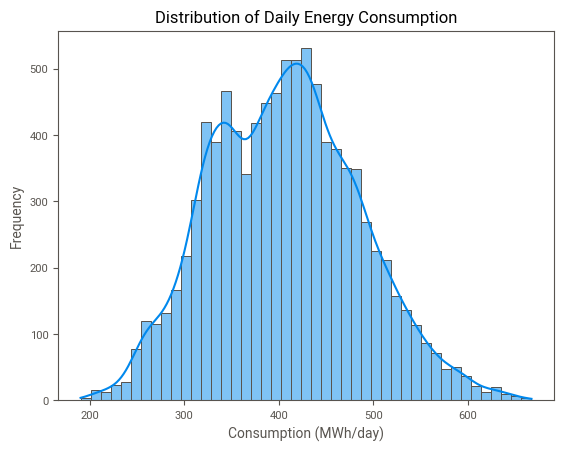

In [27]:
sns.histplot(df1['consumption_mwh_day'], kde=True)
plt.title('Distribution of Daily Energy Consumption')
plt.xlabel('Consumption (MWh/day)')
plt.ylabel('Frequency')
plt.show()

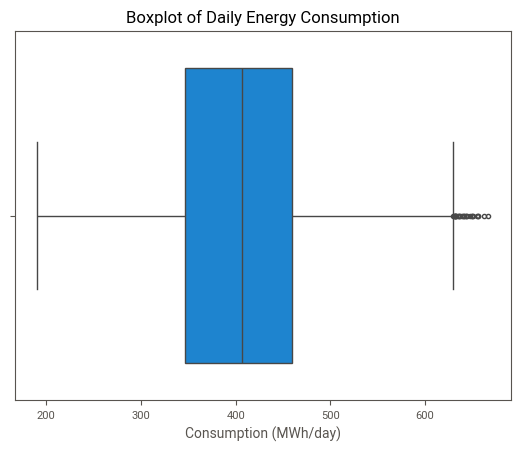

In [28]:
sns.boxplot(x=df1['consumption_mwh_day'])
plt.title('Boxplot of Daily Energy Consumption')
plt.xlabel('Consumption (MWh/day)')
plt.show()

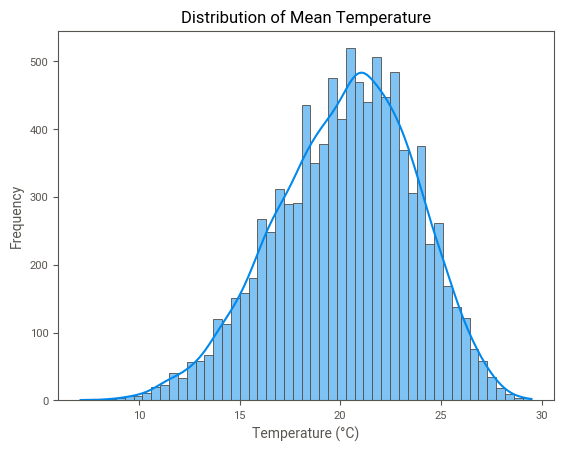

In [29]:
sns.histplot(df1['temp_mean_c'], kde=True)
plt.title('Distribution of Mean Temperature')
plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency')
plt.show()

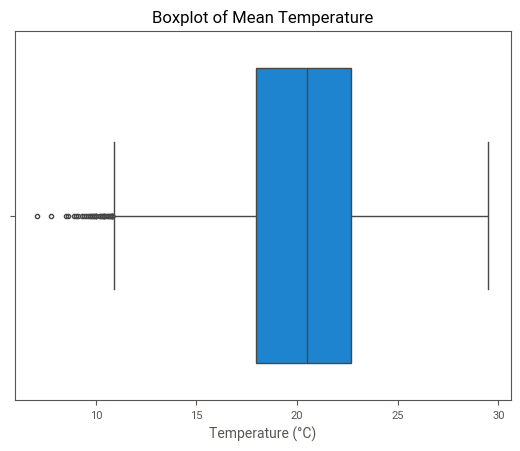

In [30]:
sns.boxplot(x=df1['temp_mean_c'])   
plt.title('Boxplot of Mean Temperature')
plt.xlabel('Temperature (°C)')
plt.show()  

# 2.0. (STEP 2) EXPLORATORY DATA ANALYSIS - EDA


In [31]:
df2 = df1.copy()

### H1. Energy consumption is expected to be higher during holidays. (Ans.: False)

In [32]:

df2_temp =df2.groupby('is_holiday')['consumption_mwh_day'].mean().reset_index()
df2_temp


,is_holiday,consumption_mwh_day
0,False,408.457566
1,True,367.000515


### H2. Energy consumption during the summer period (December-March) is expected to be higher than during the winter period (June-September). (Ans.: True)

In [33]:
df2_temp = df2.groupby('month')['consumption_mwh_day'].sum().reset_index()
df2_temp

,month,consumption_mwh_day
0,1,352335.169001
1,2,327667.844208
2,3,345684.544266
3,4,318149.121915
4,5,315150.889191
5,6,298554.283268
6,7,307758.982824
7,8,316995.414458
8,9,317273.705306
9,10,332481.617972


In [34]:
df2_temp_summer = df2_temp[df2_temp['month'].isin([12, 1, 2, 3])]
df2_temp_winter = df2_temp[df2_temp['month'].isin([6, 7, 8, 9])]
print('Summer average consumption: {} MWh'.format(df2_temp_summer['consumption_mwh_day'].sum()))
print('Winter average consumption: {} MWh'.format(df2_temp_winter['consumption_mwh_day'].sum()))

Summer average consumption: 1357980.9878315204 MWh
Winter average consumption: 1240582.3858572848 MWh


### H3. The average consumption of the last 10 years is higher than the sum of all previous years. (Ans.: True) 

In [35]:
df2['year'].unique()

array([2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010,
       2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021,
       2022, 2023, 2024, 2025, 2026], dtype=int32)

In [36]:
df2_temp = df2.groupby('year')['consumption_mwh_day'].mean().reset_index()
df2_temp

,year,consumption_mwh_day
0,2000,308.708173
1,2001,279.160443
2,2002,300.078914
3,2003,313.687892
4,2004,326.974273
5,2005,340.277962
6,2006,352.229837
7,2007,370.100835
8,2008,377.664774
9,2009,372.983131


In [37]:
df2_temp_last_10 = df2_temp[df2_temp['year'].between(2016,2026)]
df2_temp_before_last_10 = df2_temp[df2_temp['year'].between(2000,2015)]


In [38]:
print('Average consumption in the last 10 years: {} MWh'.format(df2_temp_last_10['consumption_mwh_day'].mean()))
print('Average consumption before the last 10 years: {} MWh'.format(df2_temp_before_last_10['consumption_mwh_day'].mean()))

Average consumption in the last 10 years: 477.7458592418489 MWh
Average consumption before the last 10 years: 366.3076404696415 MWh


## Time Series EDA

In [39]:
# Formatacao para graficos e tabelas
plt.style.use('ggplot')
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

In [40]:
#Formatando os labels dos graficos
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
#m.rcParams['legend.fontsize'] = 12
#m.rcParams['figure.titlesize'] = 16 
plt.rcParams['text.color'] = 'k'

In [41]:
energy_consumption_serie = df2.set_index('date')[['consumption_mwh_day']]

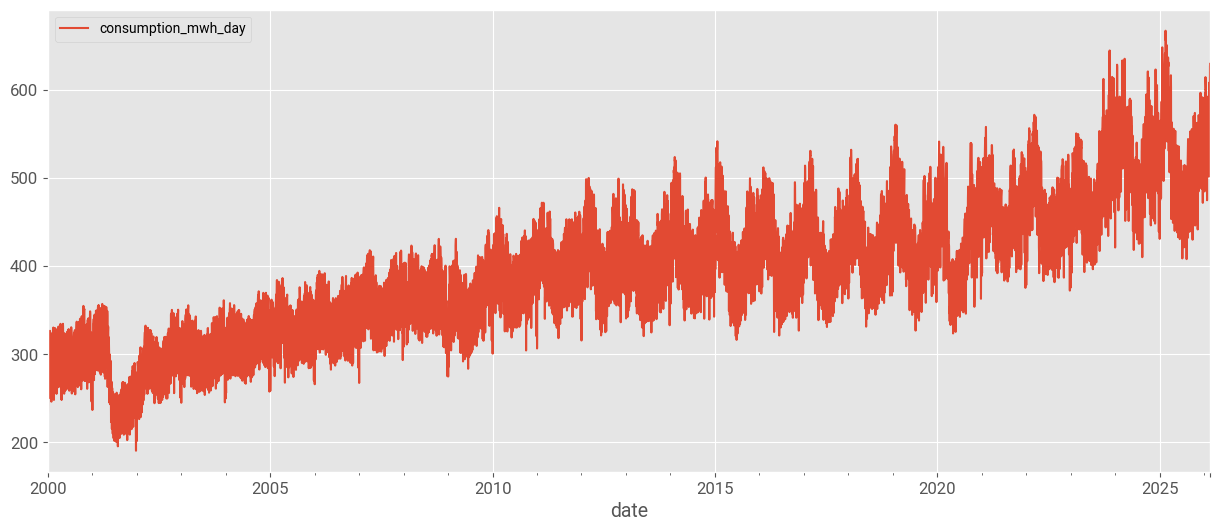

In [42]:
#Plot da Serie Temporal 
energy_consumption_serie.plot(figsize=(15,6))
plt.show()

### 1. 2001 Energy Rationing Crisis ("The Blackout Crisis")
A sharp, abrupt drop is visible at the beginning of the series (2001). This corresponds 
to the **mandatory energy rationing** imposed by the Brazilian government between June 2001 
and February 2002.

* **Cause:** Critical reservoir levels in the Southeast/Midwest regions due to 
severe droughts and a lack of infrastructure investment.
* **Impact:** A government-mandated **20% reduction target** forced a structural 
shift in consumption habits. Note that the series takes nearly two years to return 
to pre-crisis levels.

### 2. Post-2020 Dynamics: Pandemic Impact and Recent Uptrend
From 2020 onwards, the series enters a phase of higher volatility and a steeper 
positive slope:

* **COVID-19 Shock (2020):** There is a visible "dip" corresponding to the initial 
lockdowns, where industrial and commercial demand fell sharply, partially offset 
by a surge in residential load (Remote Work).
* **The Post-2021 Growth:** The sharp upward trend seen from 2021 to 2025 reflects 
economic recovery combined with **extreme heatwaves**. Increased temperatures in 
the Southeast and Midwest have driven record-breaking peaks in cooling demand 
(air conditioning), pushing the overall baseline of the series higher.

In [43]:
energy_consumption_serie.reset_index()

,date,consumption_mwh_day
0,2000-01-01,228.551950
1,2000-01-02,232.776300
2,2000-01-03,276.740950
3,2000-01-04,290.738900
4,2000-01-05,297.695250
...,...,...
9544,2026-02-17,586.724395
9545,2026-02-18,626.864414
9546,2026-02-19,628.908878
9547,2026-02-20,629.855458


Text(0.5, 1.0, 'Boxplot of Energy consumption per year')

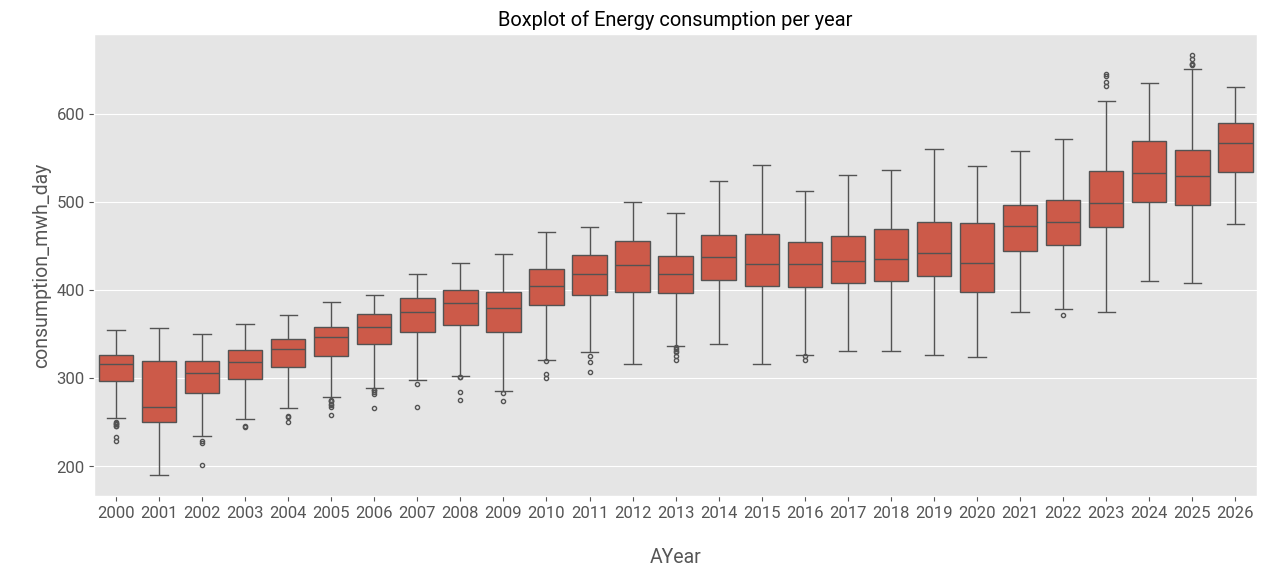

In [44]:
# Define a area de plotagem para os subplots
fig, ax = plt.subplots(1, figsize=(15,6))

#Define as variaveis
indice_ano = energy_consumption_serie.index.year
valor = energy_consumption_serie.values.flatten() # Pega os valores da série e transforma em array 1D

#Cria um boxplot  para cada ano
sns.boxplot(x=indice_ano, y=valor, ax = ax)
plt.xlabel('\nAYear')
plt.ylabel('\nconsumption_mwh_day')
plt.title('Boxplot of Energy consumption per year')

### Summary of Annual Distribution Insights
Based on the yearly boxplot analysis, we can conclude the following structural patterns:

1. **Persistent Upward Trend:** The steady increase in the median throughout the years indicates a clear ascending trend in energy consumption.
2. **Stable Structural Growth:** There is a constant increase in the values surrounding the median over time. This suggests that the entire energy demand profile is shifting upward consistently, maintaining a stable distribution while reaching higher baselines.
3. **Extreme Demand Peaks:** The presence of upper outliers in the 2023 and 2025 boxplots indicates aggressive consumption peaks. These spikes are strong indicators of extreme weather events (heatwaves) that drive cooling demand significantly beyond the typical statistical range.

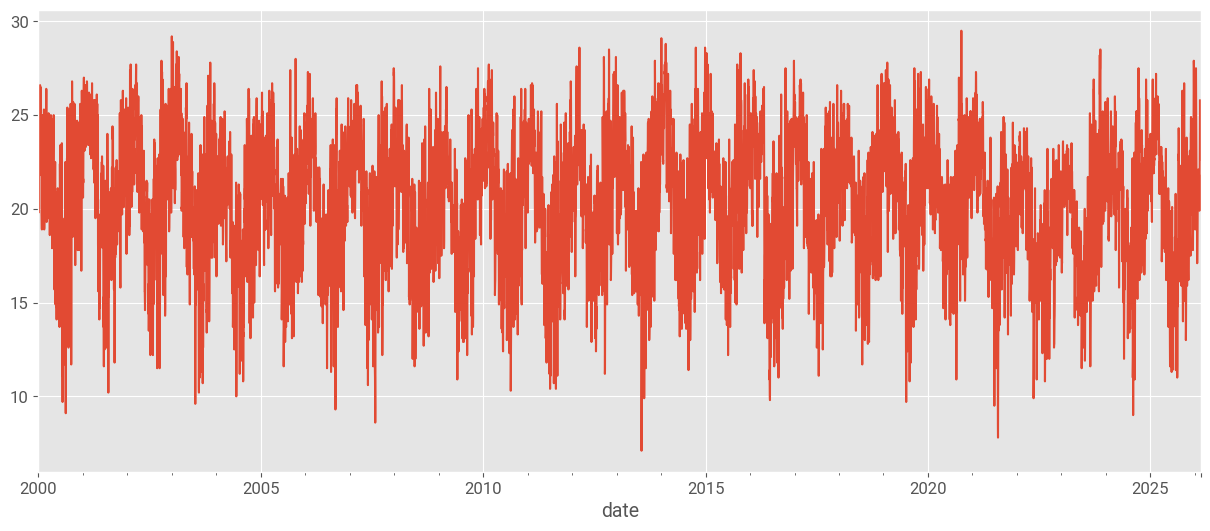

In [45]:
temperature_serie = df2.set_index('date')['temp_mean_c']
temperature_serie.plot(figsize=(15,6))
plt.show()

### 
The temperature series provides the climatic context necessary to understand energy 
demand fluctuations. We can see that in summer time when the temperature is higher the consumption is also higher

Pearson Correlation: 0.18


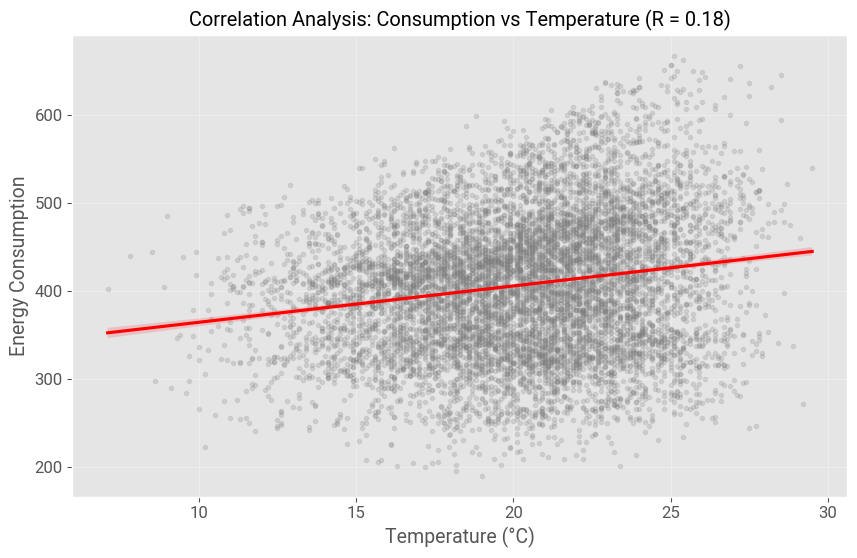

In [46]:
correlation = df2['consumption_mwh_day'].corr(df2['temp_mean_c'])
print(f"Pearson Correlation: {correlation:.2f}")

# Visualizando a relação com um Scatter Plot e Regressão Linear
plt.figure(figsize=(10, 6))
sns.regplot(data=df2, x='temp_mean_c', y='consumption_mwh_day', 
            scatter_kws={'alpha':0.2, 'color':'gray'}, 
            line_kws={'color':'red'})

plt.title(f'Correlation Analysis: Consumption vs Temperature (R = {correlation:.2f})')
plt.xlabel('Temperature (°C)')
plt.ylabel('Energy Consumption')
plt.grid(True, alpha=0.3)
plt.show()

### 
The scatter plot reveals a **weak positive correlation** (0.18) between daily temperature 
and energy consumption. While a positive trend is visible (red line), the low R-value 
suggests that temperature alone does not explain the bulk of consumption variance. In other hand we can see the higher values of energy consumption (>500) are concentrated in region with high temperature >20°C.

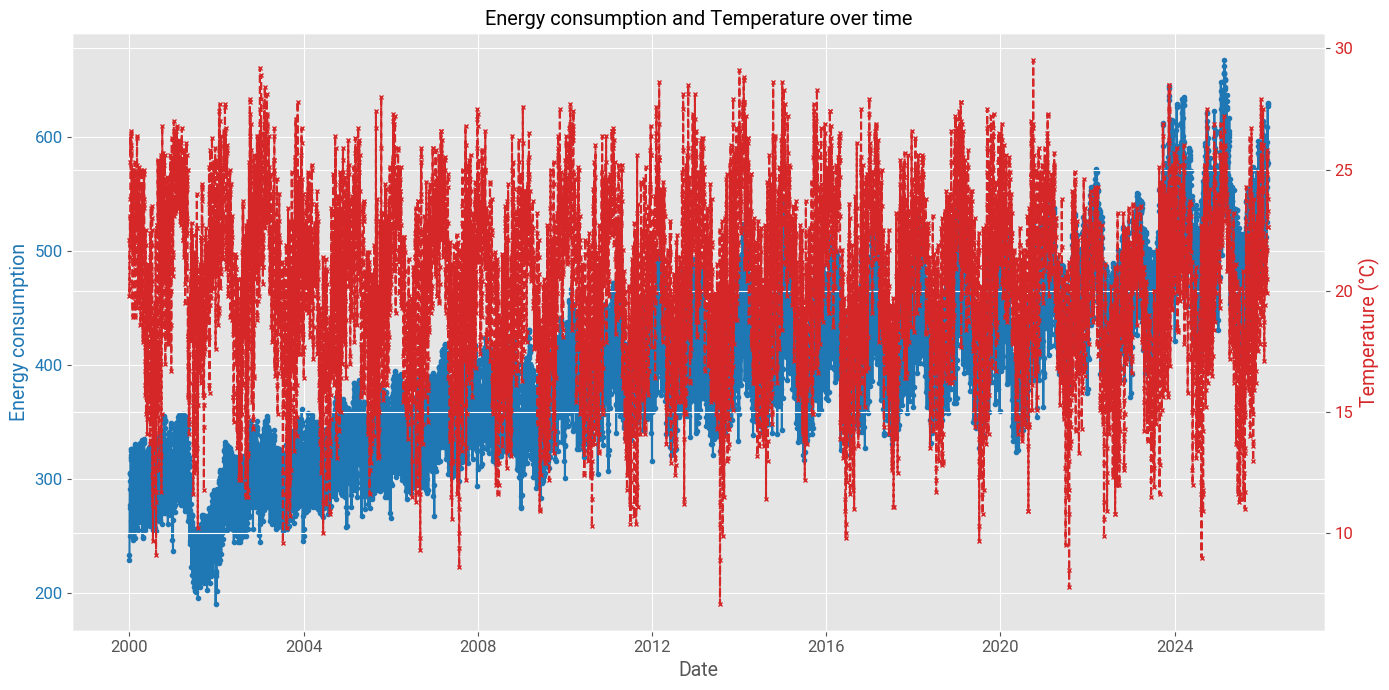

In [47]:
# Cria uma figura e eixos para os gráficos
fig, ax1 = plt.subplots(figsize=(14, 7))

# Plot do Consumo de Energia
ax1.plot(df2['date'], df2['consumption_mwh_day'], color='tab:blue', marker='o', linestyle='-', label='Energy consumption')
ax1.set_xlabel('Date')
ax1.set_ylabel('Energy consumption', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True)

# Cria um segundo eixo y para a Temperatura
ax2 = ax1.twinx() # Cria um segundo eixo Y (direito) compartilhando o eixo X, para plotar a Temperatura que tem uma escala diferente.
ax2.plot(df2['date'], df2['temp_mean_c'], color='tab:red', marker='x', linestyle='--', label='Temperature')
ax2.set_ylabel('Temperature (°C)', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

# Adiciona título e legendas
plt.title('Energy consumption and Temperature over time')
fig.tight_layout()  # Para ajustar bem o layout
plt.show()

In [48]:
#For past 10 years only
df2_temp_plot = df2[df2['date'].between('2016-01-01', '2026-12-31')].copy()

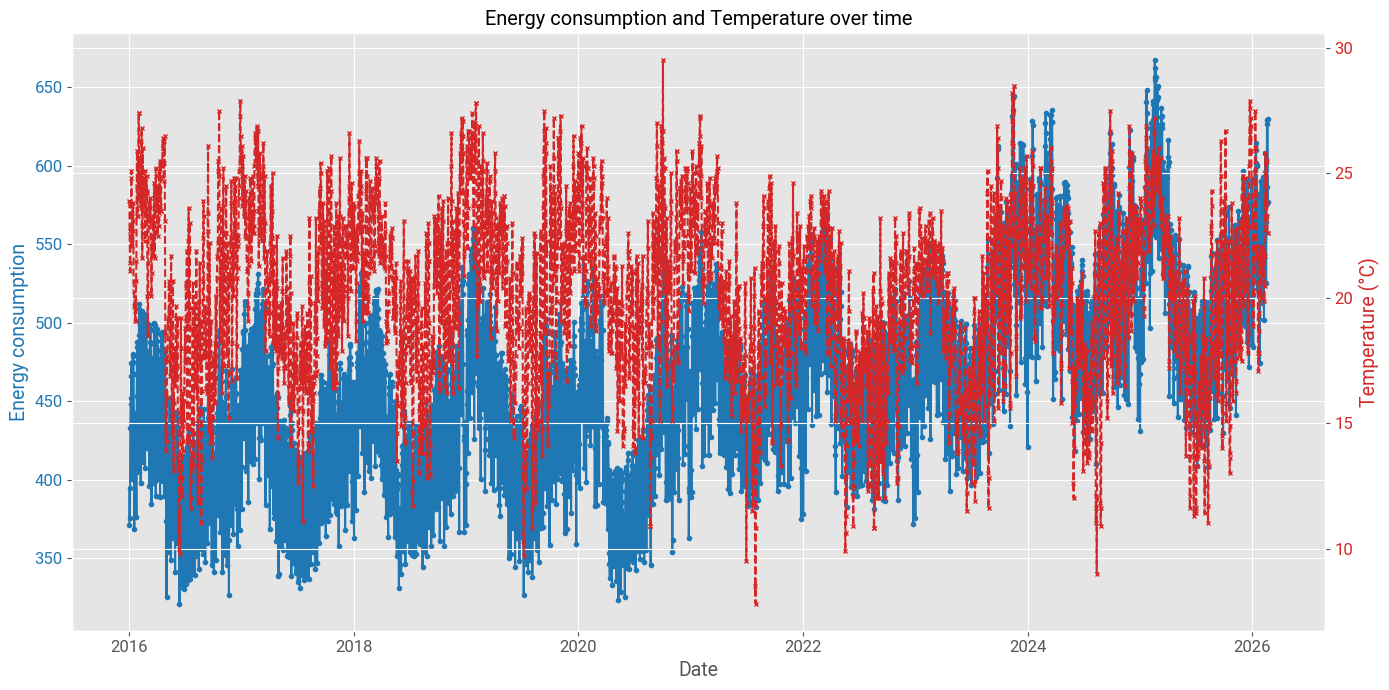

In [49]:
# Cria uma figura e eixos para os gráficos
fig, ax1 = plt.subplots(figsize=(14, 7))

# Plot do Consumo de Energia
ax1.plot(df2_temp_plot['date'], df2_temp_plot['consumption_mwh_day'], color='tab:blue', marker='o', linestyle='-', label='Energy consumption')
ax1.set_xlabel('Date')
ax1.set_ylabel('Energy consumption', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True)

# Cria um segundo eixo y para a Temperatura
ax2 = ax1.twinx() # Cria um segundo eixo Y (direito) compartilhando o eixo X, para plotar a Temperatura que tem uma escala diferente.
ax2.plot(df2_temp_plot['date'], df2_temp_plot['temp_mean_c'], color='tab:red', marker='x', linestyle='--', label='Temperature')
ax2.set_ylabel('Temperature (°C)', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

# Adiciona título e legendas
plt.title('Energy consumption and Temperature over time')
fig.tight_layout()  # Para ajustar bem o layout
plt.show()

### Historical data (2016-2026) showing energy consumption following temperature trends.Temperature peaks drive higher energy consumption.

# 3.0. (STEP 3) TIME SERIES DECOMPOSITION AND STATISTICAL PROPERTIES


In [50]:
df3 = df2.copy()

In [51]:
df3= df3.set_index('date')
#df3.reset_index(inplace=True)
df3.head()

,consumption_mwh_day,temp_mean_c,is_holiday,year,month
date,,,,,
2000-01-01,228.55195,22.1,True,2000,1
2000-01-02,232.77630,19.8,False,2000,1
2000-01-03,276.74095,20.1,False,2000,1
2000-01-04,290.73890,20.4,False,2000,1
2000-01-05,297.69525,21.4,False,2000,1


In [52]:
df3.index

DatetimeIndex(['2000-01-01', '2000-01-02', '2000-01-03', '2000-01-04', '2000-01-05', '2000-01-06', '2000-01-07', '2000-01-08', '2000-01-09', '2000-01-10',
               ...
               '2026-02-12', '2026-02-13', '2026-02-14', '2026-02-15', '2026-02-16', '2026-02-17', '2026-02-18', '2026-02-19', '2026-02-20', '2026-02-21'], dtype='datetime64[ns]', name='date', length=9549, freq=None)

In [53]:
#Cehckando valores nulos
df3.isnull().sum()

consumption_mwh_day    0
temp_mean_c            0
is_holiday             0
year                   0
month                  0
dtype: int64

In [54]:
# Multiplicative decomposition is chosen since the size of seasonal fluctuations scales proportionally with the overall trend. ALso the resid does not have a pattern (which we want)
dec_energy = sm.tsa.seasonal_decompose(df3['consumption_mwh_day'], model='multiplicative',period=365,extrapolate_trend='freq') 
 

Text(0.5, 1.05, 'Multiplicative Decomposition of Energy Consumption')

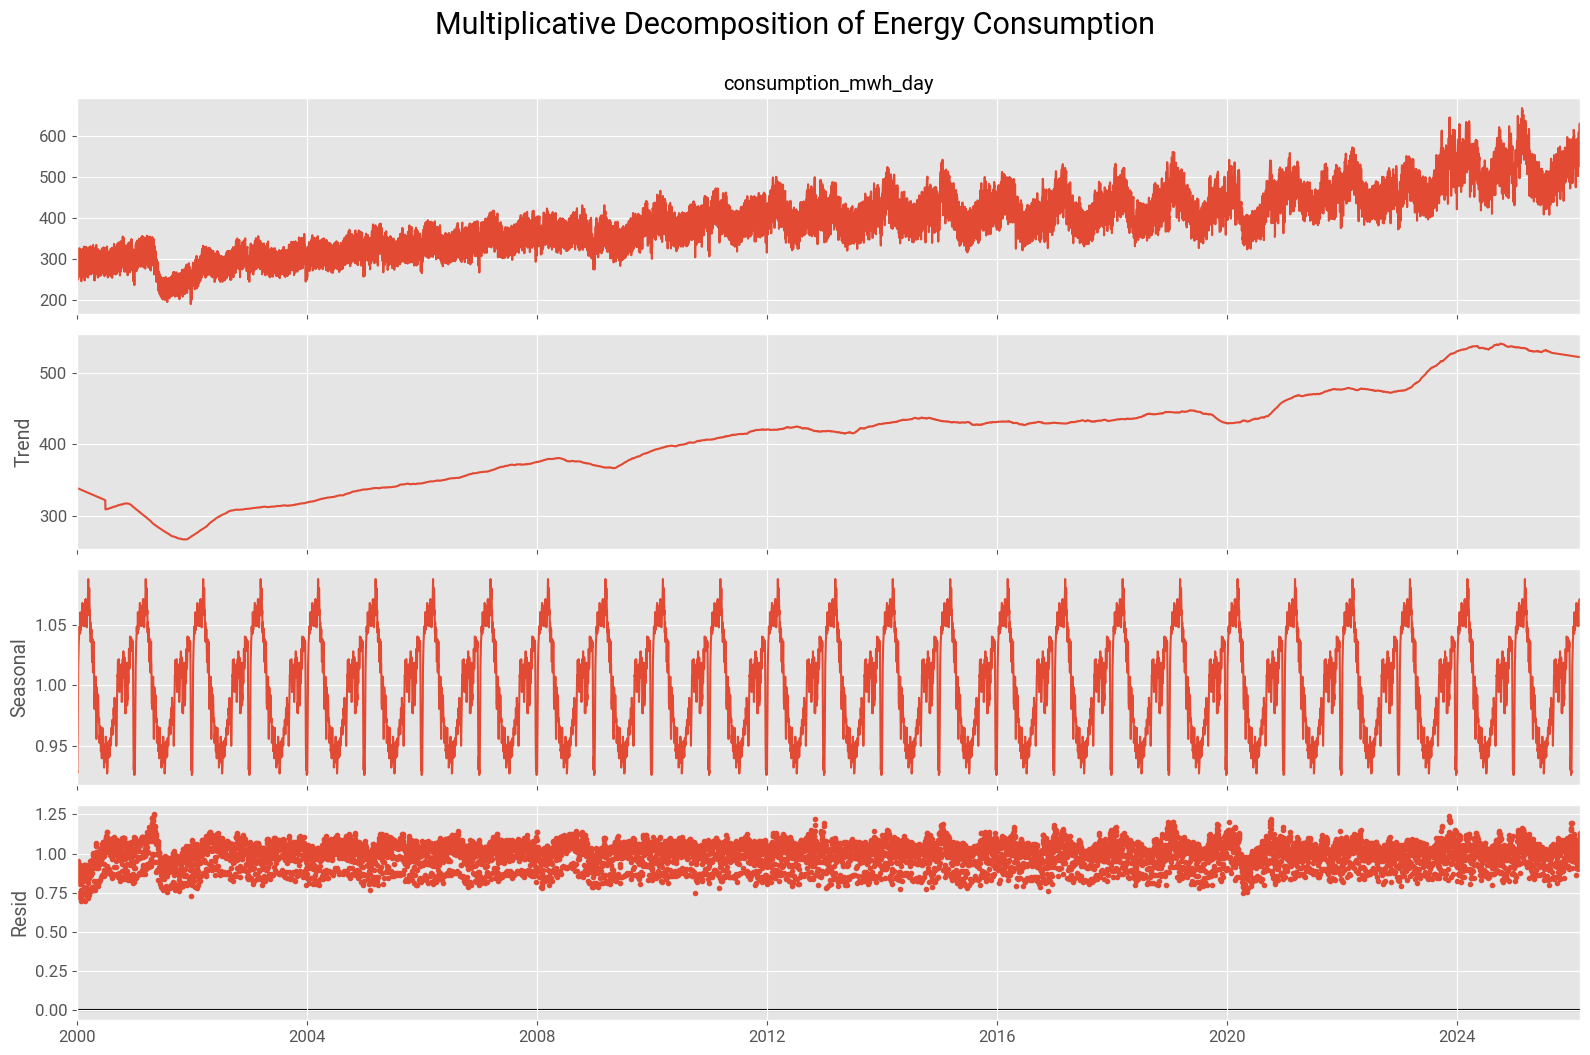

In [55]:
#Plot
plt.rcParams.update({'figure.figsize':(16,10)})
dec_energy.plot().suptitle('Multiplicative Decomposition of Energy Consumption', fontsize=22,y=1.05)

### The energy consumption shows a clear long-term upward trend with a stable multiplicative seasonal pattern, where the amplitude of fluctuations increases proportionally as the overall demand grows over time.

In [56]:
# Used additive model for temperature because the seasonal variation remains constant over time and also we can dealling with value 0 of temperature in case of any
dec_temperature = sm.tsa.seasonal_decompose(df3['temp_mean_c'], model='additive',period=365,extrapolate_trend='freq') 

Text(0.5, 1.05, 'Additive Decomposition of Temperature')

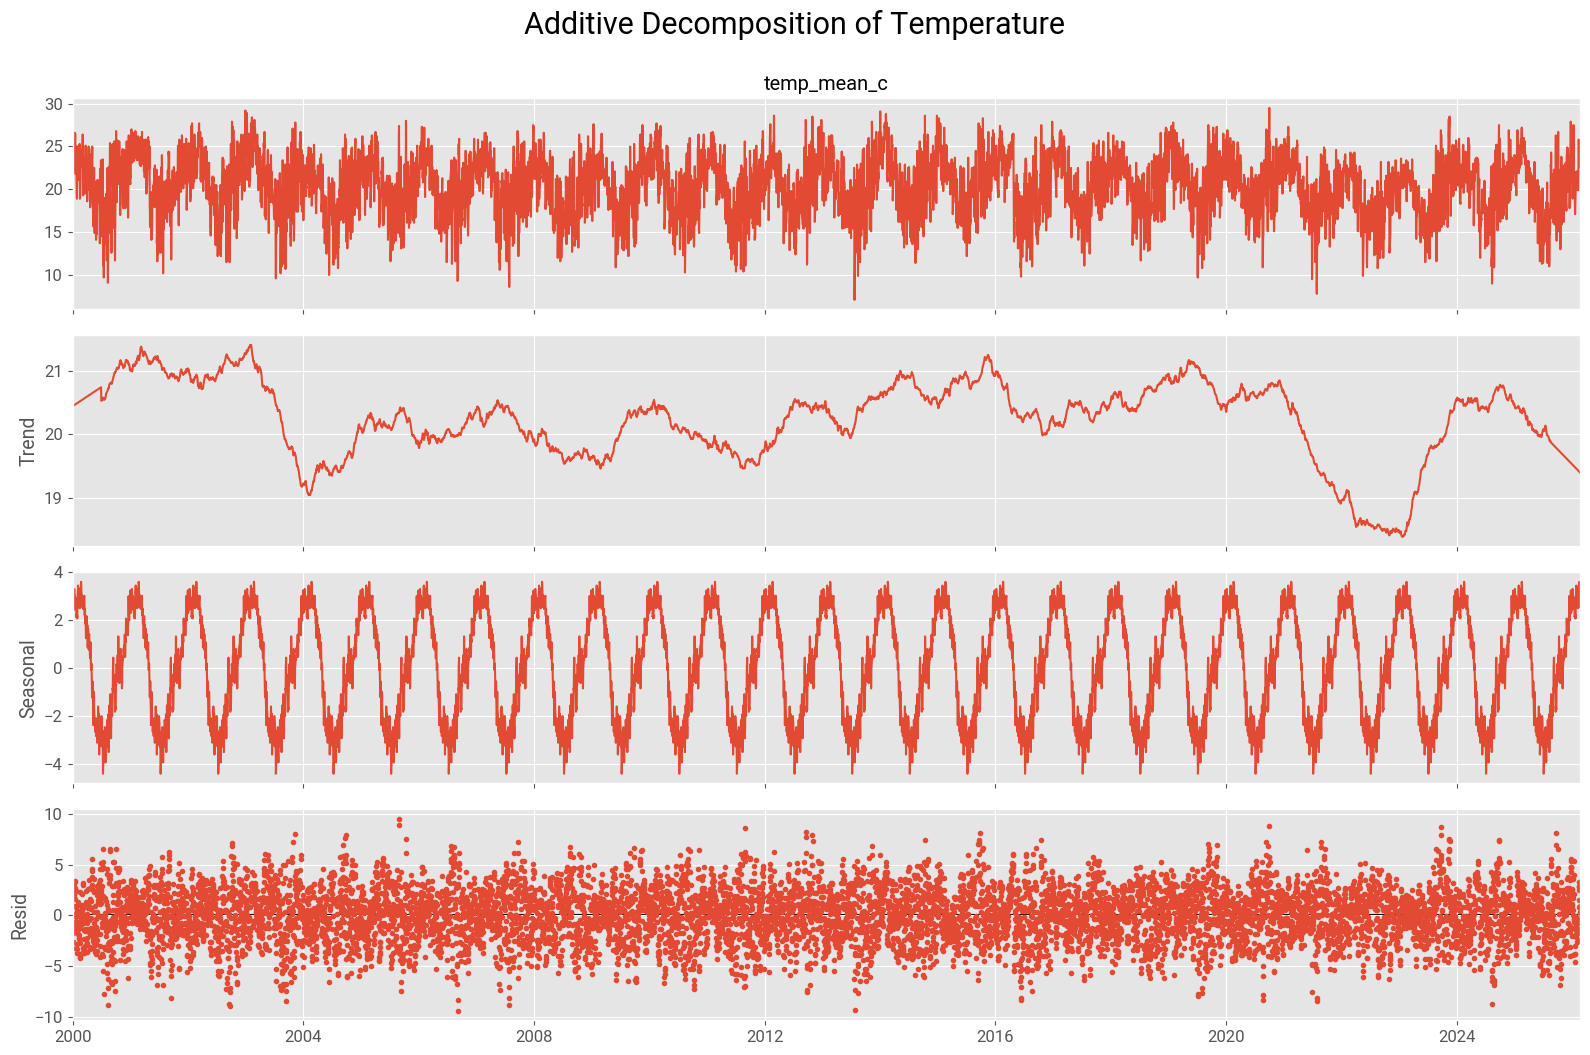

In [57]:
#Plot
plt.rcParams.update({'figure.figsize':(16,10)})
dec_temperature.plot().suptitle('Additive Decomposition of Temperature', fontsize=22,y=1.05)

### 
The temperature series exhibits a highly stable annual seasonality coupled with a non-linear, oscillating trend that lacks a clear long-term direction, while the significant residuals reflect the inherent daily volatility of weather patterns.

## Rolling Statistics

In [58]:
#Determinando Estatisticas moveis
rolmean = df3['consumption_mwh_day'].rolling(window=12).mean()
rolstd = df3['consumption_mwh_day'].rolling(window=12).std()

In [59]:
#PRepara os dados para plot
x = df3.index
y = df3['consumption_mwh_day'].values

#### Rolling mean and STD

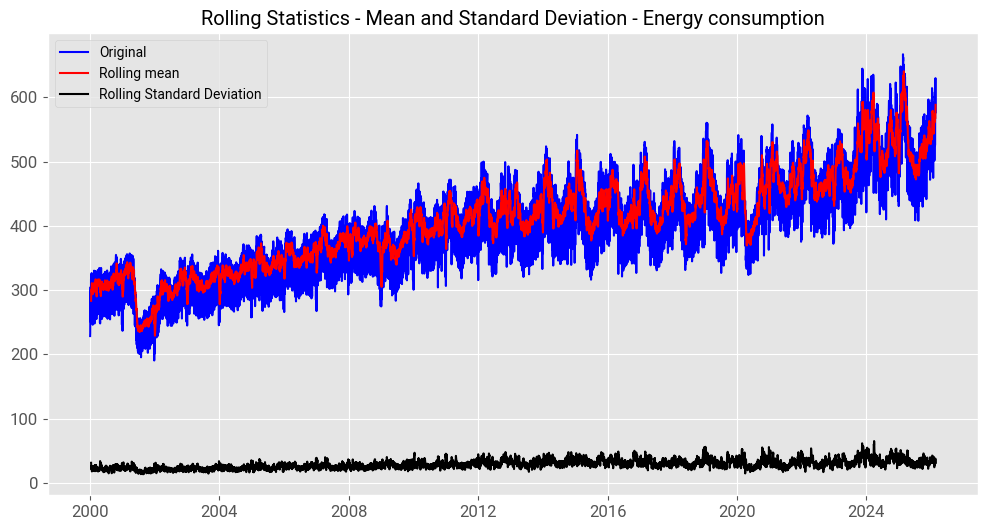

In [60]:
#Plot das estatisticas moveis
plt.figure(figsize=(12,6))
orig = plt.plot(x, y, color='blue',label='Original')
mean = plt.plot(x, rolmean, color='red', label='Rolling mean')
std = plt.plot(x, rolstd, color='black', label='Rolling Standard Deviation')
plt.legend(loc='best')
plt.title('Rolling Statistics - Mean and Standard Deviation - Energy consumption')
plt.show()

###
The red line (Rolling Mean) clearly smooths the daily original serie (blue) and highlights the long-term growth and the 2001 anomaly.
STD: It isn't flat; it shows a slight but steady increase over the decades. This proves that as the mean consumption grows, the variance (the "spread" of the peaks and valleys) also grows. Also we see rolling mean growing over the years.


In [61]:
#Determinando Estatisticas moveis
rolmean = df3['temp_mean_c'].rolling(window=12).mean()
rolstd = df3['temp_mean_c'].rolling(window=12).std()

In [62]:
#PRepara os dados para plot
x = df3.index
y = df3['temp_mean_c'].values

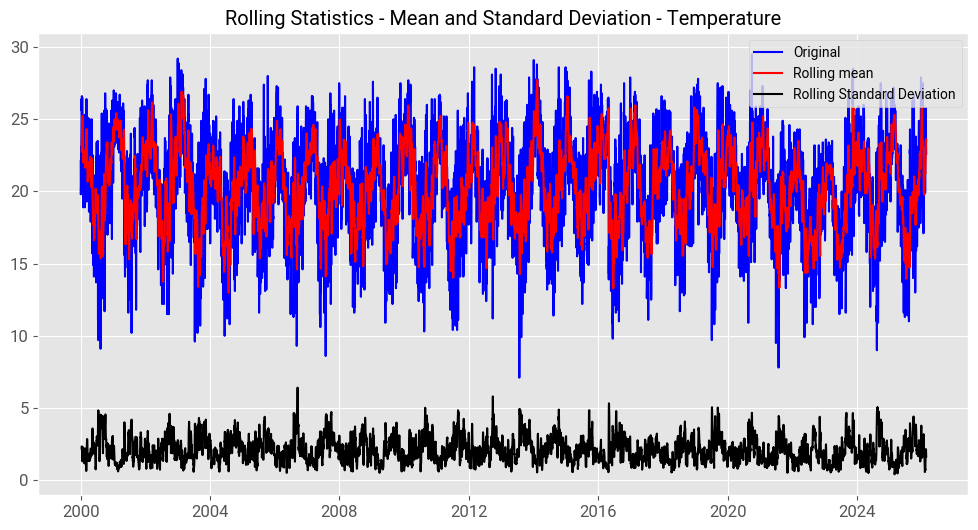

In [63]:
#Plot das estatisticas moveis
plt.figure(figsize=(12,6))
orig = plt.plot(x, y, color='blue',label='Original')
mean = plt.plot(x, rolmean, color='red', label='Rolling mean')
std = plt.plot(x, rolstd, color='black', label='Rolling Standard Deviation')
plt.legend(loc='best')
plt.title('Rolling Statistics - Mean and Standard Deviation - Temperature')
plt.show()

####
"The temperature series exhibits stationarity in variance but remains non-stationary in mean due to its strong, recurring seasonal cycles; while the rolling standard deviation is remarkably constant (homoscedastic), the rolling mean fluctuates within a 3°C range without a definitive long-term trend."

### Autocorrelation (ACF) and Partial Autocorrelation (PACF)

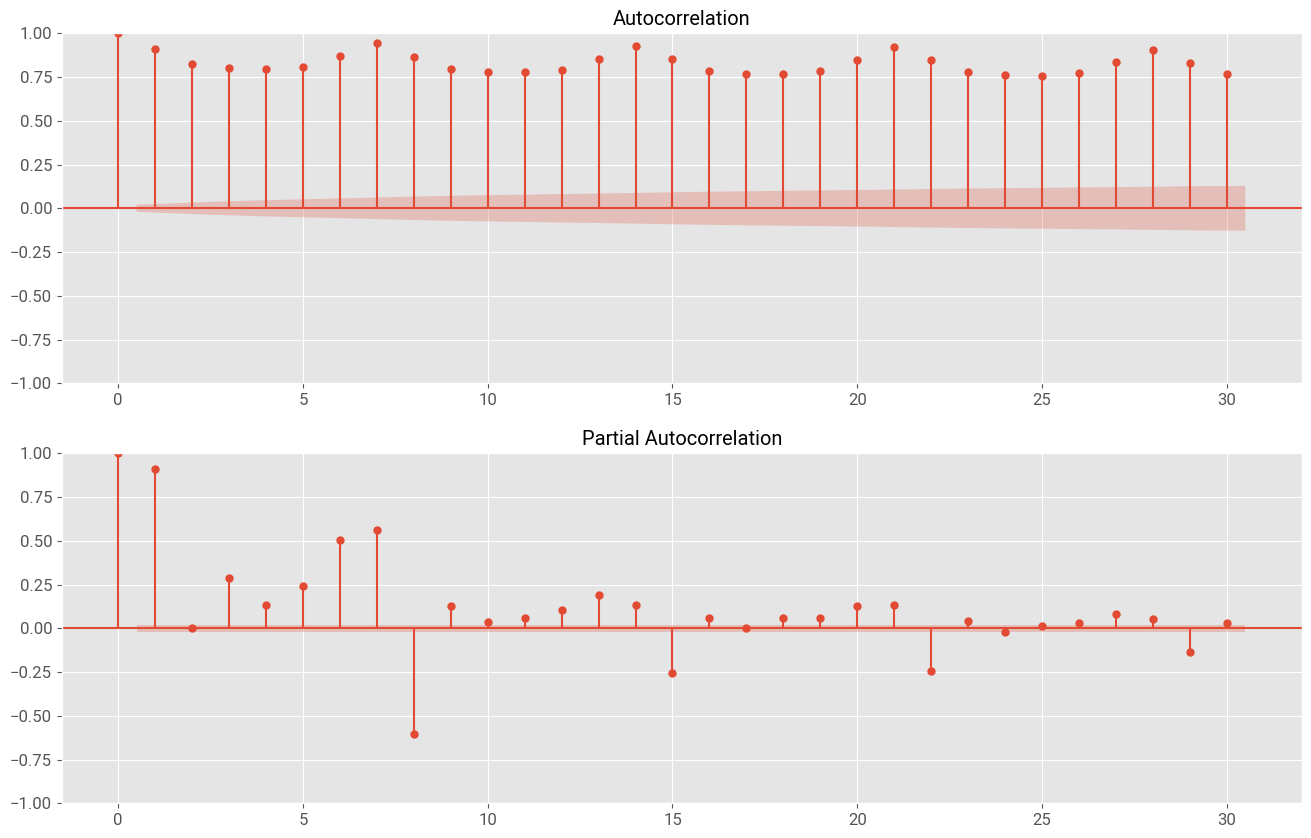

In [64]:
#Plots
plt.rcParams.update({'figure.figsize':(16,10)})
                    
#Plot do Grafico ACF
plt.subplot(211)
plot_acf(df3.consumption_mwh_day, ax=plt.gca(), lags=30)

#Plot do Grafico PACF
plt.subplot(212)
plot_pacf(df3.consumption_mwh_day, ax=plt.gca(), lags=30, method='ywm')
plt.show()

In [65]:
# O lag igual a 30 indica que vai compara no inicio lag 1(defasagem de 1) o que eh normal ter alta correlacao, 
# porem com o aumento do lag a correlacao vai diminuindo ate chegar proximo de 0 e defino o limite com 30 observacoes para tras, 
# ou seja no inicio uma observacao tem correlacao com a observacao anterior, mas pouca com a 30gesia atrasquero algo mais auto explicativo


In [ ]:
''' -----------------------ACF---------------------------
* A área sombreada ACF é o intervalo de confiança (geralmente 95%) para a hipótese de correlação zero em cada lag; 
   barras fora dessa faixa sugerem autocorrelação estatisticamente diferente de zero naquele lag
* Os dados dessa série temporal provavelmente não são estacionários, pois a ACF permanece alta em vários lags (decaimento lento),
   indicando forte persistência (valores passados influenciam valores futuros por muitos períodos)
* Acima da área sombreada há autocorrelação significativa (diferente de zero) no respectivo lag
* Cada barra indica o nível de correlação entre y(t) e y(t-lag); à medida que o lag aumenta, a correlação tende a diminuir,
   sugerindo que observações mais distantes têm menor influência direta na observação atual
* A cada 7 observações vemos a correlação aumentar em relação às anteriores (indicando sazonalidade semanal);
  isso evidencia dependência temporal na série. Para ARIMA, podemos testar d = 1 para diferenciar a série e reduzir a persistência;
  se a sazonalidade semanal for forte, também pode ser necessário considerar componente sazonal com s = 7 (SARIMA).
'''


' -----------------------ACF---------------------------\n* A área sombreada ACF é o intervalo de confiança (geralmente 95%) para a hipótese de correlação zero em cada lag; \n   barras fora dessa faixa sugerem autocorrelação estatisticamente diferente de zero naquele lag\n* Os dados dessa série temporal provavelmente não são estacionários, pois a ACF permanece alta em vários lags (decaimento lento),\n   indicando forte persistência (valores passados influenciam valores futuros por muitos períodos)\n* Acima da área sombreada há autocorrelação significativa (diferente de zero) no respectivo lag\n* Cada barra indica o nível de correlação entre y(t) e y(t-lag); à medida que o lag aumenta, a correlação tende a diminuir,\n   sugerindo que observações mais distantes têm menor influência direta na observação atual\n* A cada 7 observações vemos a correlação aumentar em relação às anteriores (indicando sazonalidade semanal);\n  isso evidencia dependência temporal na série. Para ARIMA, podemos tes

In [67]:
''' ---------------------PACF---------------------------
* O gráfico PACF mostra a correlação parcial entre a série temporal e suas defasagens, controlando para as defasagens intermediárias. 
* Ele ajuda a sugerir o número de defasagens autoregressivas (p) em um modelo ARIMA, indicando quais defasagens têm uma correlação significativa com a série temporal, mesmo após controlar para as defasagens anteriores.
* No grafico vemos que tem uma dependencia direta da serie concentrada nos primeiros lags (principalmente no lag 1), enquanto os demais lags tendem a ter efeito direto menor (muitos próximos de zero/dentro do IC).
'''


' ---------------------PACF---------------------------\n* O gráfico PACF mostra a correlação parcial entre a série temporal e suas defasagens, controlando para as defasagens intermediárias. \n* Ele ajuda a sugerir o número de defasagens autoregressivas (p) em um modelo ARIMA, indicando quais defasagens têm uma correlação significativa com a série temporal, mesmo após controlar para as defasagens anteriores.\n* No grafico vemos que tem uma dependencia direta da serie concentrada nos primeiros lags (principalmente no lag 1), enquanto os demais lags tendem a ter efeito direto menor (muitos próximos de zero/dentro do IC).\n'

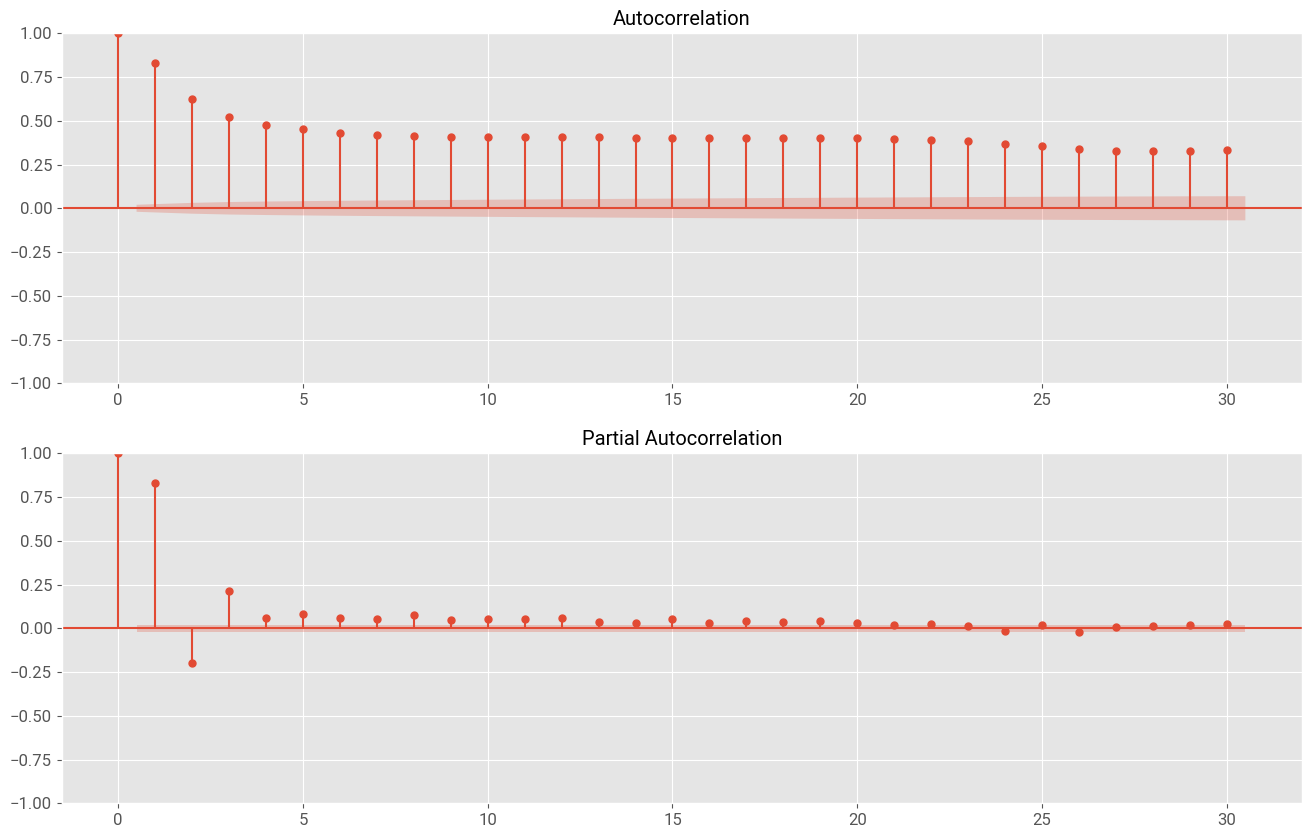

In [68]:
#Plots
plt.rcParams.update({'figure.figsize':(16,10)})
                    
#Plot do Grafico ACF
plt.subplot(211)
plot_acf(df3.temp_mean_c, ax=plt.gca(), lags=30)

#Plot do Grafico PACF
plt.subplot(212)
plot_pacf(df3.temp_mean_c, ax=plt.gca(), lags=30, method='ywm')
plt.show()

In [69]:
''' 
* A ACF para a temperatura mostra um padrão de decaimento mais rápido do que o consumo, sugerindo que a temperatura é menos persistente 
e pode ser mais próxima de estacionariedade.
* O PACF para a temperatura indica que a autocorrelação parcial é significativa apenas nos primeiros lags, 
especialmente no lag 1, o que sugere que um modelo AR(1) pode ser adequado para modelar a temperatura, 
enquanto os lags mais distantes não têm uma influência direta significativa após controlar para os lags anteriores.
'''

' \n* A ACF para a temperatura mostra um padrão de decaimento mais rápido do que o consumo, sugerindo que a temperatura é menos persistente \ne pode ser mais próxima de estacionariedade.\n* O PACF para a temperatura indica que a autocorrelação parcial é significativa apenas nos primeiros lags, \nespecialmente no lag 1, o que sugere que um modelo AR(1) pode ser adequado para modelar a temperatura, \nenquanto os lags mais distantes não têm uma influência direta significativa após controlar para os lags anteriores.\n'

### Test Augmented Dickey-Fuller (ADF) for stationarity

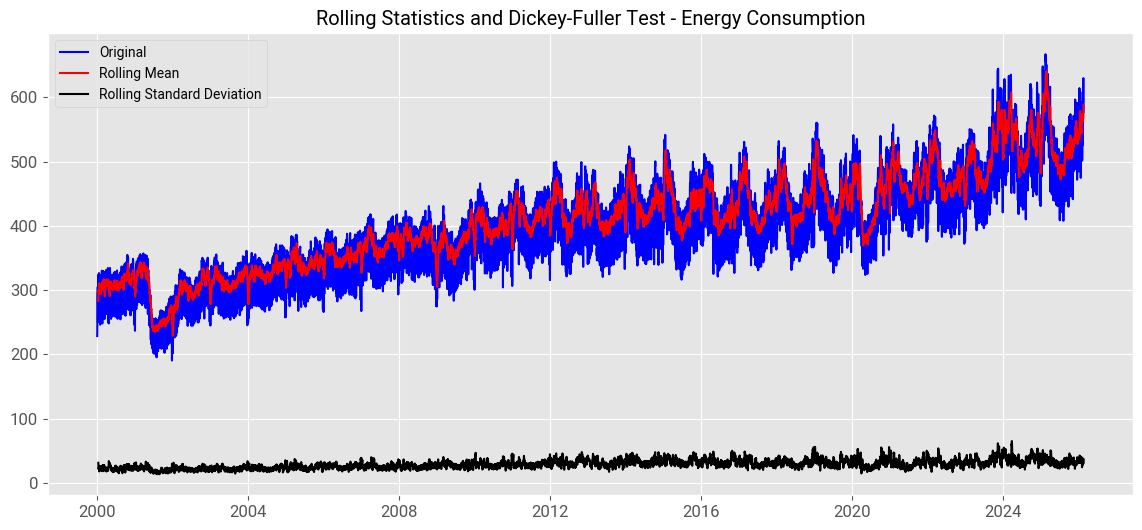


Results of Dickey-Fuller Test:
Test Statistic                   -2.103606
p-value                           0.243067
Number of Lags Used              38.000000
Number of Observations Used    9510.000000
Critical Value (1%)              -3.431038
Critical Value (5%)              -2.861844
Critical Value (10%)             -2.566932
dtype: float64

Conclusion:
The p-value is greater than 0.05; therefore, we fail to reject the null hypothesis. The series is likely non-stationary.


In [70]:
test_stationarity (df3['consumption_mwh_day'], window=12, title='Rolling Statistics and Dickey-Fuller Test - Energy Consumption')

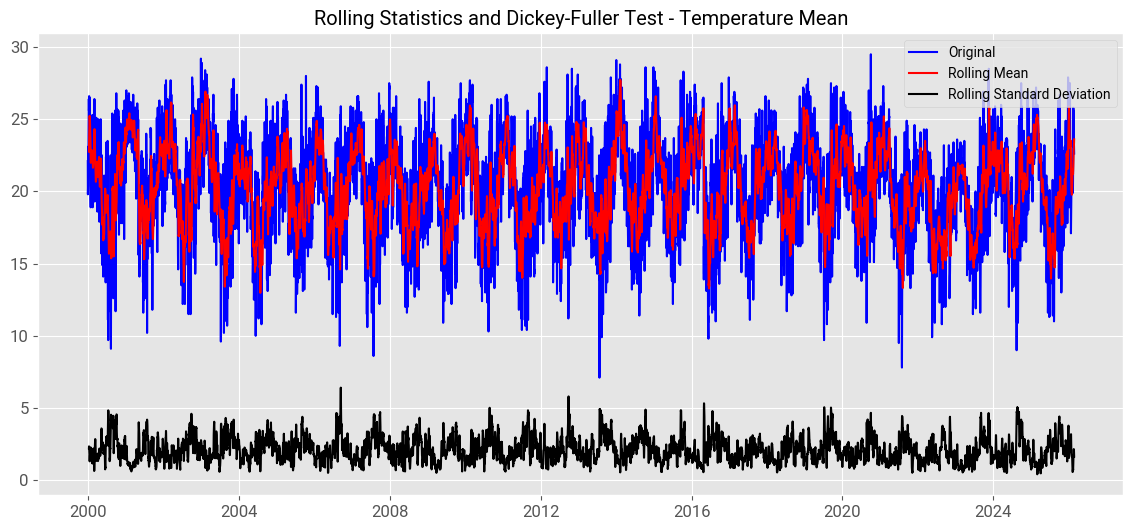


Results of Dickey-Fuller Test:
Test Statistic                -7.558520e+00
p-value                        3.053715e-11
Number of Lags Used            3.100000e+01
Number of Observations Used    9.517000e+03
Critical Value (1%)           -3.431037e+00
Critical Value (5%)           -2.861844e+00
Critical Value (10%)          -2.566932e+00
dtype: float64

Conclusion:
The p-value is less than 0.05; therefore, we have evidence to reject the null hypothesis. This series is likely stationary.



In [71]:
test_stationarity (df3['temp_mean_c'], window=12, title='Rolling Statistics and Dickey-Fuller Test - Temperature Mean')

# 4.0. (STEP 4) TIME SERIES TRANSFORMATION


In [77]:
df4 = df3.copy()

In [ ]:
# WE saw in previous step that Energy consumption data is no stationary and temperature is, 
# therefore we need to transform the energy consumption data to make it stationary, 
# while we can keep the temperature data as it is for modeling. 

### Log transformation

In [78]:
#Transformacao de Log
df4_log = df4.copy()
df4_log['consumption_mwh_day'] = np.log(df4['consumption_mwh_day'])
df4_log.head()

,consumption_mwh_day,temp_mean_c,is_holiday,year,month
date,,,,,
2000-01-01,5.431764,22.1,True,2000,1
2000-01-02,5.450078,19.8,False,2000,1
2000-01-03,5.623082,20.1,False,2000,1
2000-01-04,5.672426,20.4,False,2000,1
2000-01-05,5.696070,21.4,False,2000,1


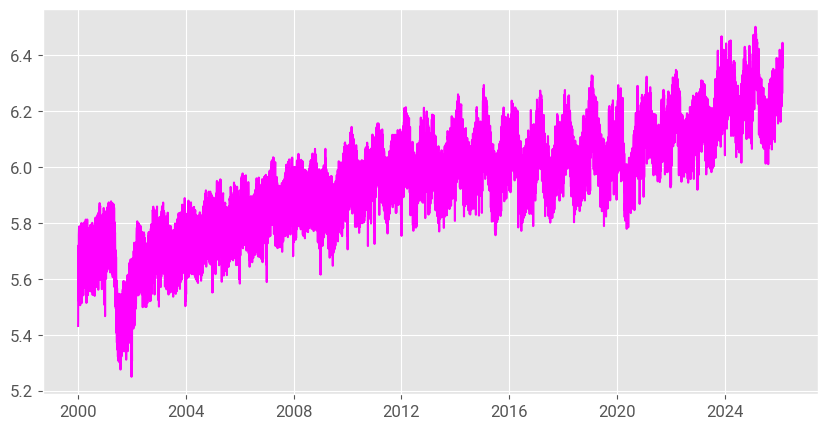

In [79]:
#Plot da serie transaformada
plt.figure(figsize=(10,5))
plt.plot(df4_log['consumption_mwh_day'],color="magenta")
plt.show()

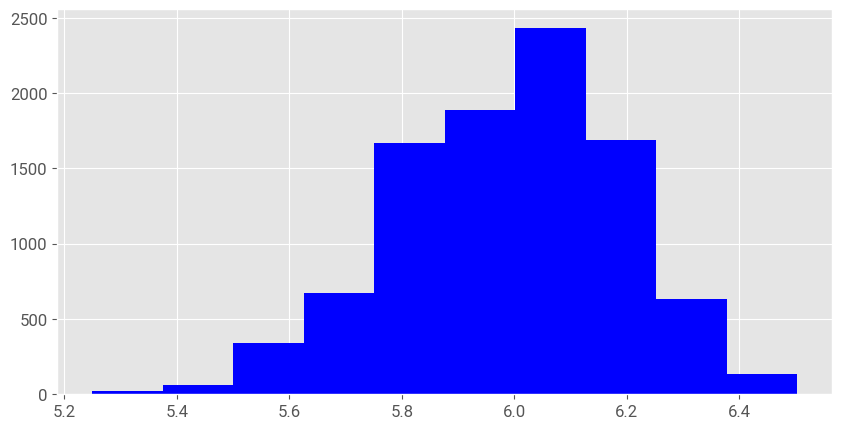

In [80]:
#Histograma da serie  transformada
plt.figure(figsize=(10,5))
plt.hist(df4_log['consumption_mwh_day'], color="blue")
plt.show()

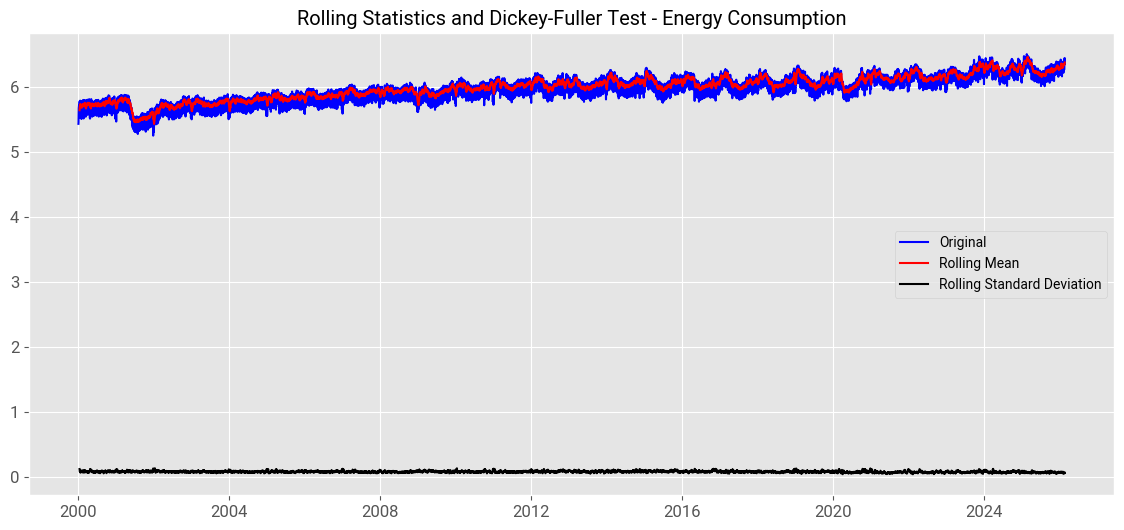


Results of Dickey-Fuller Test:
Test Statistic                   -2.107685
p-value                           0.241436
Number of Lags Used              38.000000
Number of Observations Used    9510.000000
Critical Value (1%)              -3.431038
Critical Value (5%)              -2.861844
Critical Value (10%)             -2.566932
dtype: float64

Conclusion:
The p-value is greater than 0.05; therefore, we fail to reject the null hypothesis. The series is likely non-stationary.


In [81]:
test_stationarity (df4_log['consumption_mwh_day'], window=12, title='Rolling Statistics and Dickey-Fuller Test - Energy Consumption')

### Box Cox Tranforming

In [82]:
#Aplicando TRansformacao Box-Cox
df4_bc=df4.copy()
df4_bc['consumption_mwh_day_boxcox'],lamb_value = boxcox(df4_bc['consumption_mwh_day'])
print('Valor Ideal de Lambda: %f' % lamb_value)
df4_bc.head()

Valor Ideal de Lambda: 0.604507


,consumption_mwh_day,temp_mean_c,is_holiday,year,month,consumption_mwh_day_boxcox
date,,,,,,
2000-01-01,228.55195,22.1,True,2000,1,42.464266
2000-01-02,232.77630,19.8,False,2000,1,42.955423
2000-01-03,276.74095,20.1,False,2000,1,47.873481
2000-01-04,290.73890,20.4,False,2000,1,49.373079
2000-01-05,297.69525,21.4,False,2000,1,50.107669


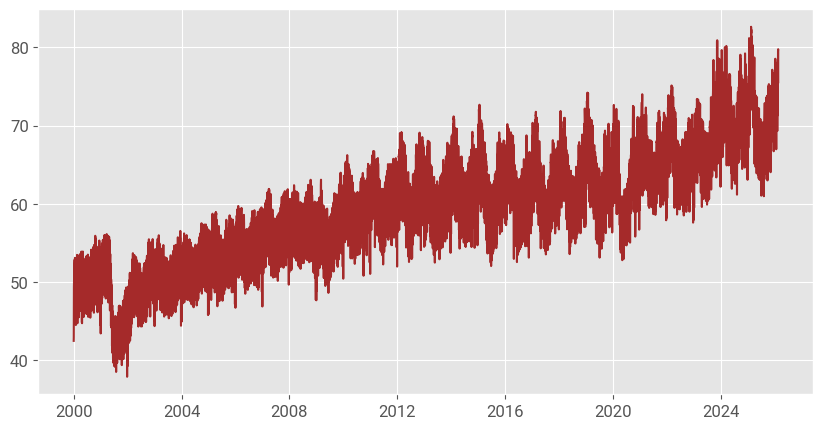

In [83]:
#Plot da Serie Transformada 
plt.figure(figsize=(10,5))
plt.plot(df4_bc['consumption_mwh_day_boxcox'], color="brown")
plt.show()

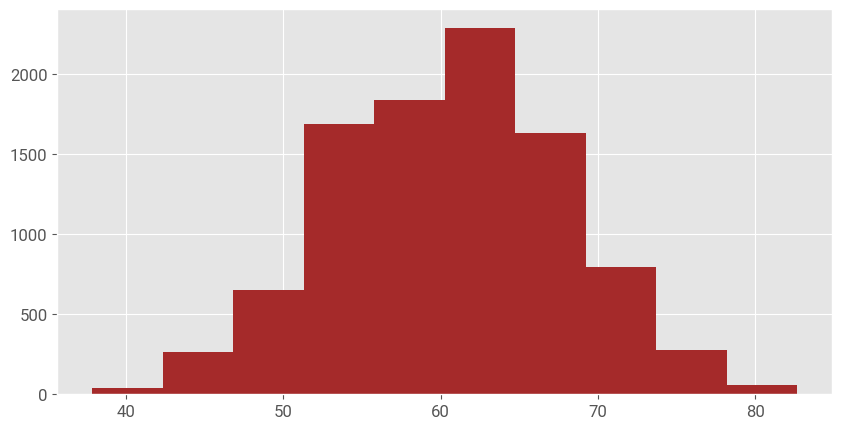

In [84]:
#Histograma
plt.figure(figsize=(10,5))
plt.hist(df4_bc['consumption_mwh_day_boxcox'], color="brown")
plt.show()

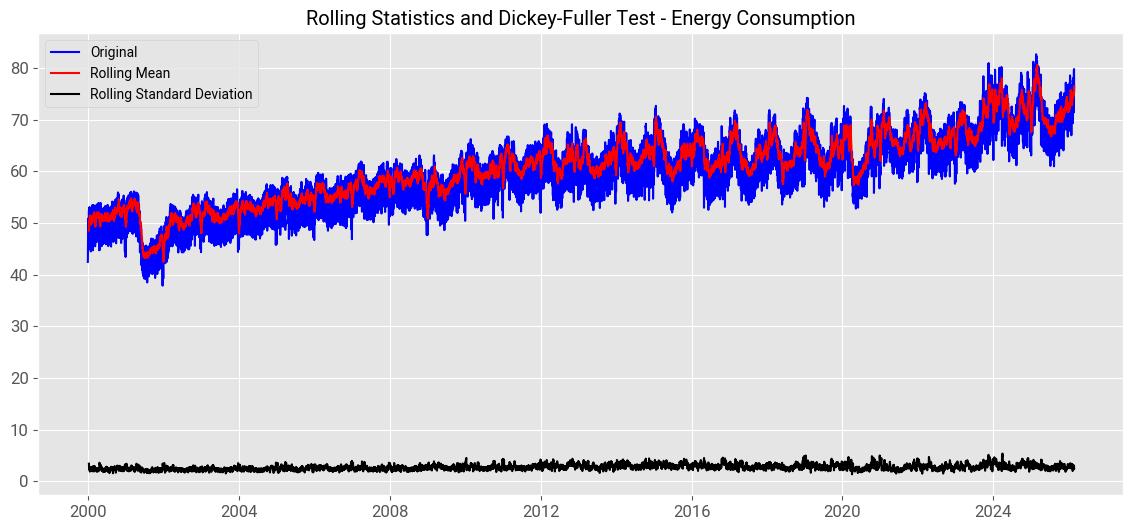


Results of Dickey-Fuller Test:
Test Statistic                   -2.094942
p-value                           0.246553
Number of Lags Used              38.000000
Number of Observations Used    9510.000000
Critical Value (1%)              -3.431038
Critical Value (5%)              -2.861844
Critical Value (10%)             -2.566932
dtype: float64

Conclusion:
The p-value is greater than 0.05; therefore, we fail to reject the null hypothesis. The series is likely non-stationary.


In [85]:
test_stationarity (df4_bc['consumption_mwh_day_boxcox'], window=12, title='Rolling Statistics and Dickey-Fuller Test - Energy Consumption')

### Simple Moving Average (SMA)

In [90]:
df4_sma = df4.copy()

In [91]:
#Definindo uma janela de 12 meses da serie temporal para calcular media movel
df4_sma['consumption_mwh_day_sma'] = df4_sma['consumption_mwh_day'].rolling(window=12).mean()
df4_sma.head(13)

,consumption_mwh_day,temp_mean_c,is_holiday,year,month,consumption_mwh_day_sma
date,,,,,,
2000-01-01,228.55195,22.1,True,2000,1,NaN
2000-01-02,232.77630,19.8,False,2000,1,NaN
2000-01-03,276.74095,20.1,False,2000,1,NaN
2000-01-04,290.73890,20.4,False,2000,1,NaN
2000-01-05,297.69525,21.4,False,2000,1,NaN
2000-01-06,304.01575,23.1,False,2000,1,NaN
2000-01-07,304.92230,22.1,False,2000,1,NaN
2000-01-08,274.39410,23.0,False,2000,1,NaN
2000-01-09,250.19025,23.8,False,2000,1,NaN


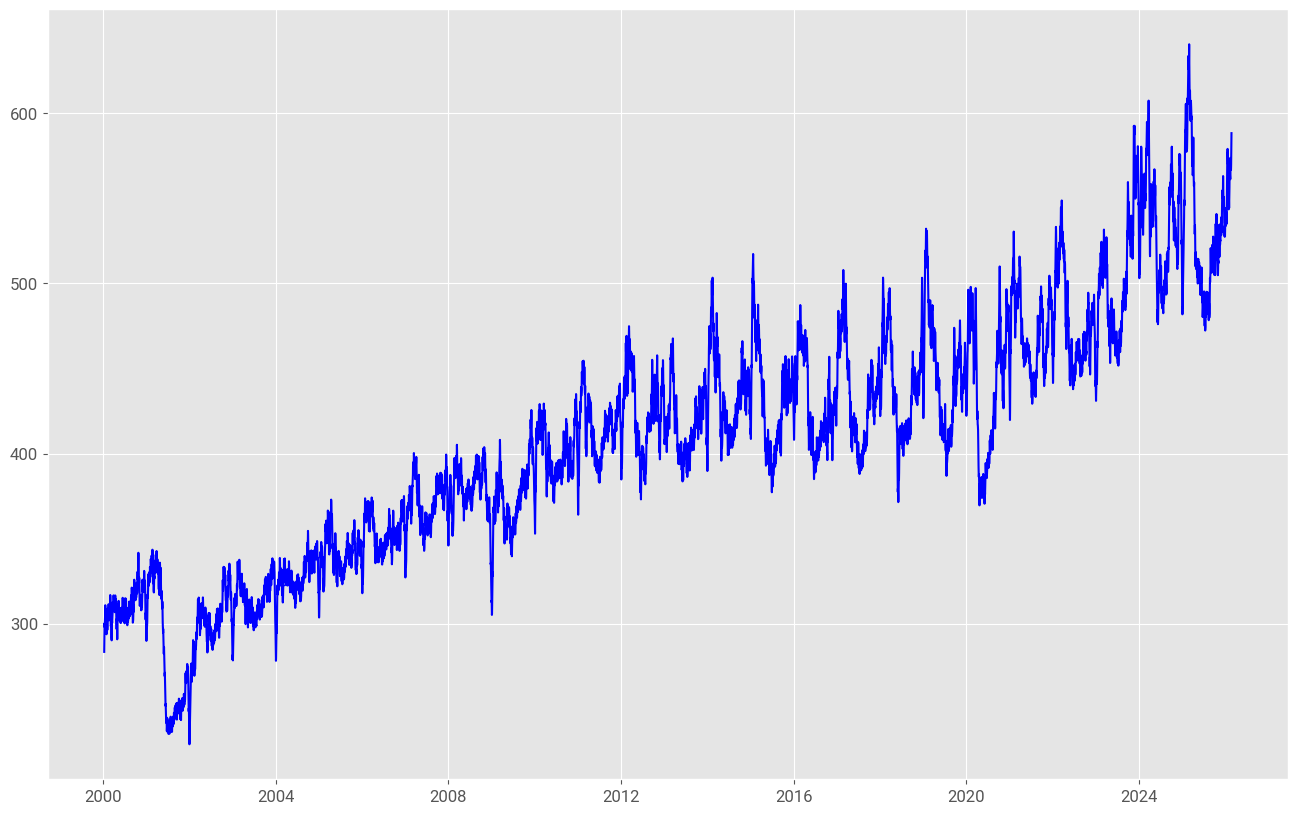

In [92]:
#Plot da serie suavizada
plt.plot(df4_sma['consumption_mwh_day_sma'],color='blue')
plt.show()

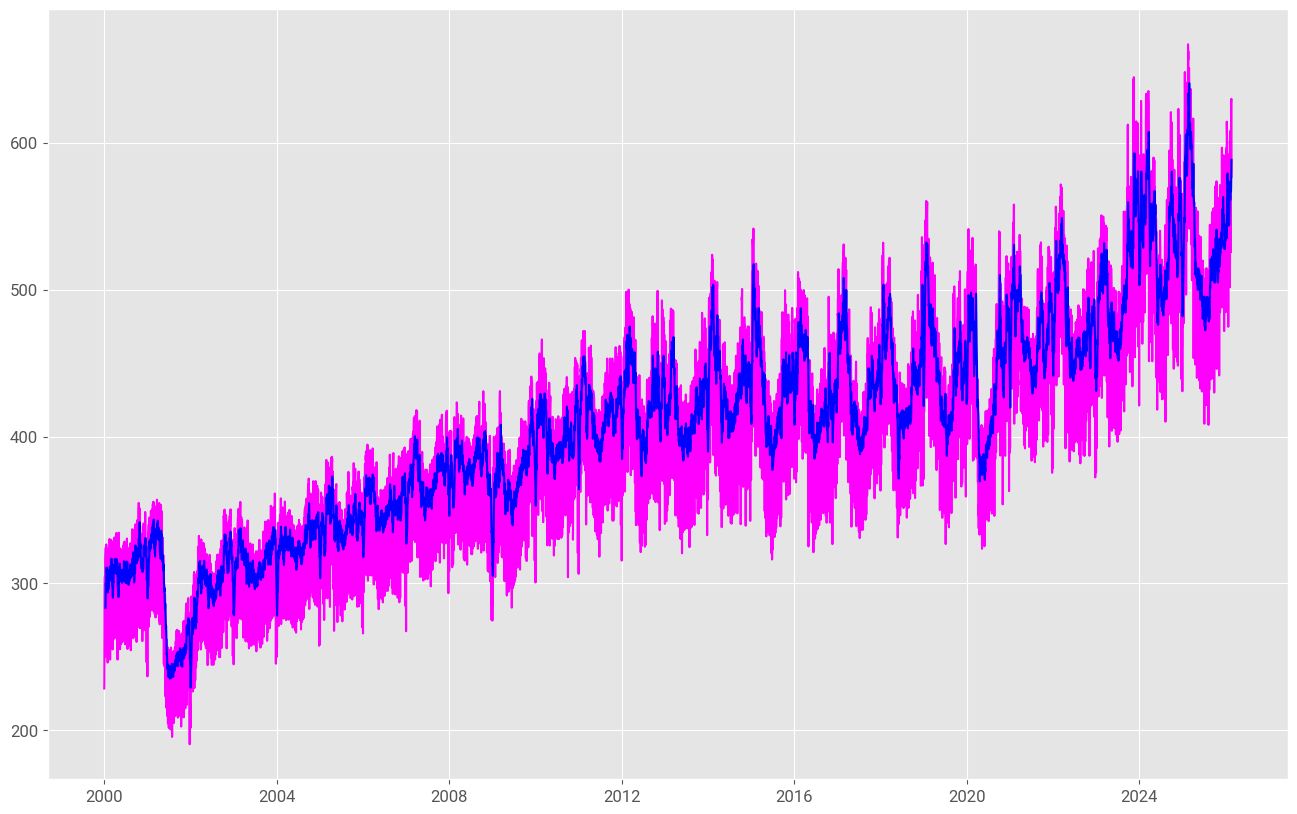

In [93]:
plt.plot(df4_sma['consumption_mwh_day'],color='magenta')
plt.plot(df4_sma['consumption_mwh_day_sma'],color='blue')
plt.show()

In [94]:
# Calculando a diferenca entre serie original e serie suavizada
diff_original_smoothed = df4_sma['consumption_mwh_day'] - df4_sma['consumption_mwh_day_sma']
diff_original_smoothed.tail(20)

date
2026-02-02    29.896631
2026-02-03    32.761964
2026-02-04    30.399212
2026-02-05    21.995007
2026-02-06    19.492280
2026-02-07   -19.585416
2026-02-08   -64.840540
2026-02-09    -7.383372
2026-02-10     1.055967
2026-02-11    18.239679
2026-02-12    30.048727
2026-02-13    34.515655
2026-02-14    -8.451892
2026-02-15   -42.252356
2026-02-16     8.410411
2026-02-17    19.899419
2026-02-18    57.202112
2026-02-19    52.961363
2026-02-20    43.225470
2026-02-21   -11.583660
dtype: float64

In [95]:
diff_original_smoothed.dropna(inplace=True)

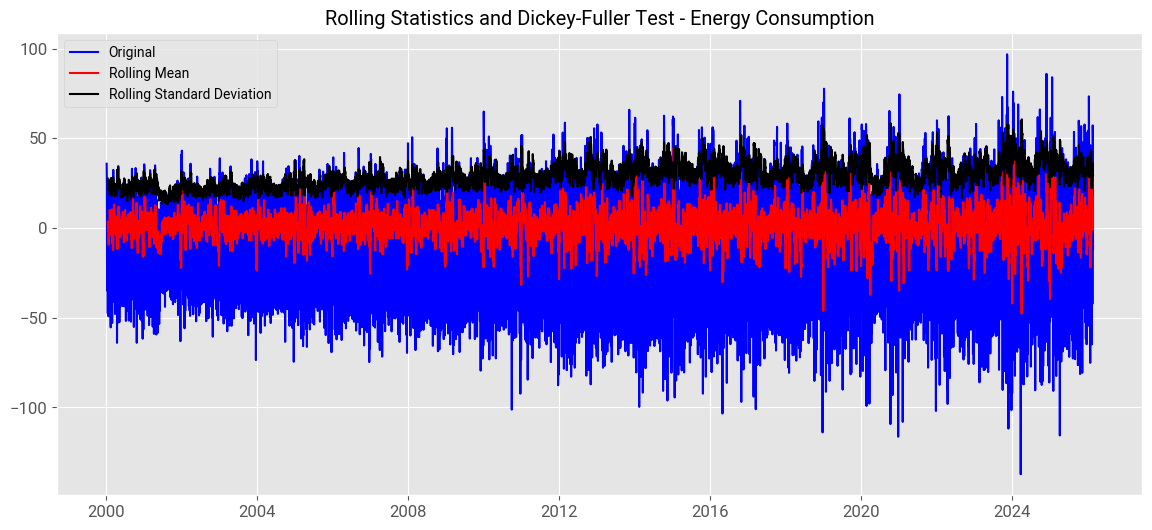


Results of Dickey-Fuller Test:
Test Statistic                  -19.951123
p-value                           0.000000
Number of Lags Used              37.000000
Number of Observations Used    9500.000000
Critical Value (1%)              -3.431039
Critical Value (5%)              -2.861844
Critical Value (10%)             -2.566932
dtype: float64

Conclusion:
The p-value is less than 0.05; therefore, we have evidence to reject the null hypothesis. This series is likely stationary.



In [96]:
test_stationarity (diff_original_smoothed, window=12, title='Rolling Statistics and Dickey-Fuller Test - Energy Consumption')

In [ ]:
'''
"While the Simple Moving Average (SMA) successfully achieved stationarity—as confirmed by the Augmented Dickey-Fuller 
test—this came at the cost of signal fidelity. The smoothing process introduced a significant temporal lag and effectively 
filtered out high-frequency volatility that may contain valuable predictive information. Consequently, further analysis 
using alternative methods, such as Differencing and Exponential Smoothing, 
is necessary to balance statistical stability with the preservation of critical short-term patterns."
'''

### Differencing

In [121]:
df4_diff = df4.copy()
df4_diff.head()


,consumption_mwh_day,temp_mean_c,is_holiday,year,month
date,,,,,
2000-01-01,228.55195,22.1,True,2000,1
2000-01-02,232.77630,19.8,False,2000,1
2000-01-03,276.74095,20.1,False,2000,1
2000-01-04,290.73890,20.4,False,2000,1
2000-01-05,297.69525,21.4,False,2000,1


In [122]:
#Applying the square root transformation to adjust the scale and reduce the impact of large values, which can help in stabilizing the variance and making the series more stationary.
df4_diff = np.sqrt(df4_diff['consumption_mwh_day'])


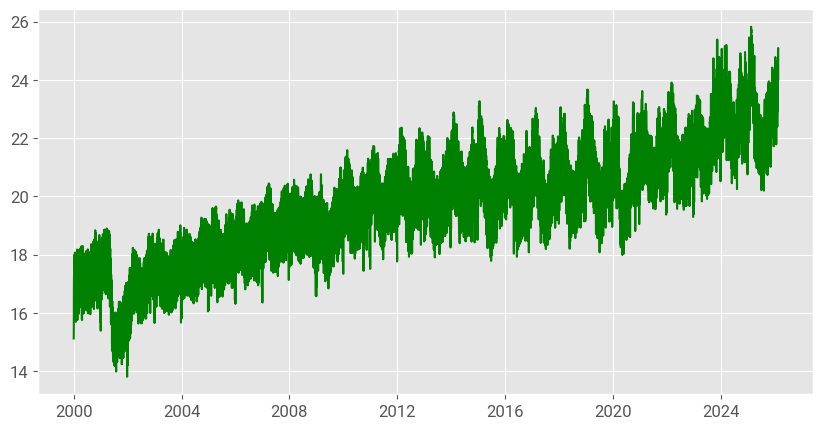

In [123]:
#Grafico de Linhas
plt.figure(figsize=(10,5))
plt.plot(df4_diff, color="green")
plt.show()

In [124]:
df4_diff.head()

date
2000-01-01    15.117935
2000-01-02    15.257008
2000-01-03    16.635533
2000-01-04    17.051067
2000-01-05    17.253847
Name: consumption_mwh_day, dtype: float64

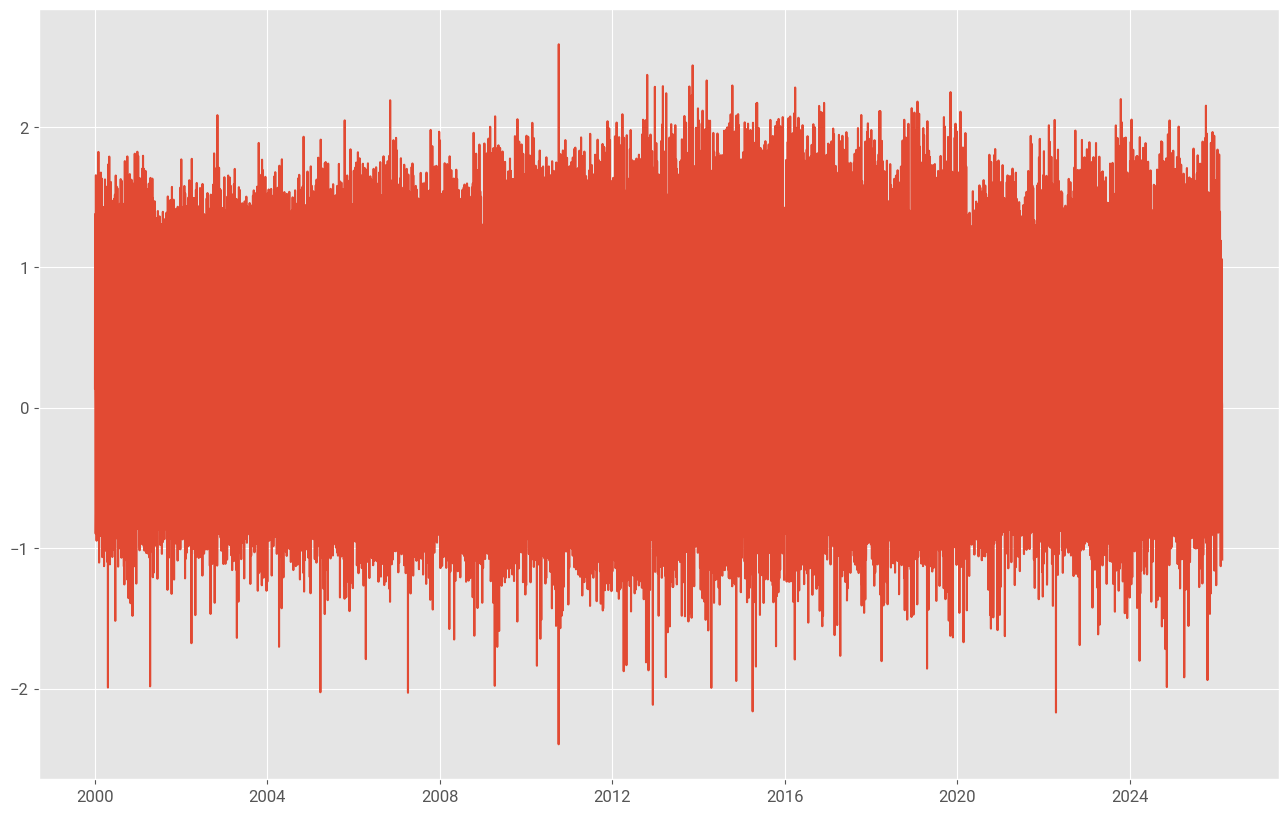

In [125]:
#Diferenciacao para remover tendencia
df4_diff2 = diffFunc(df4_diff)
plt.plot(df4_diff2)
plt.show()

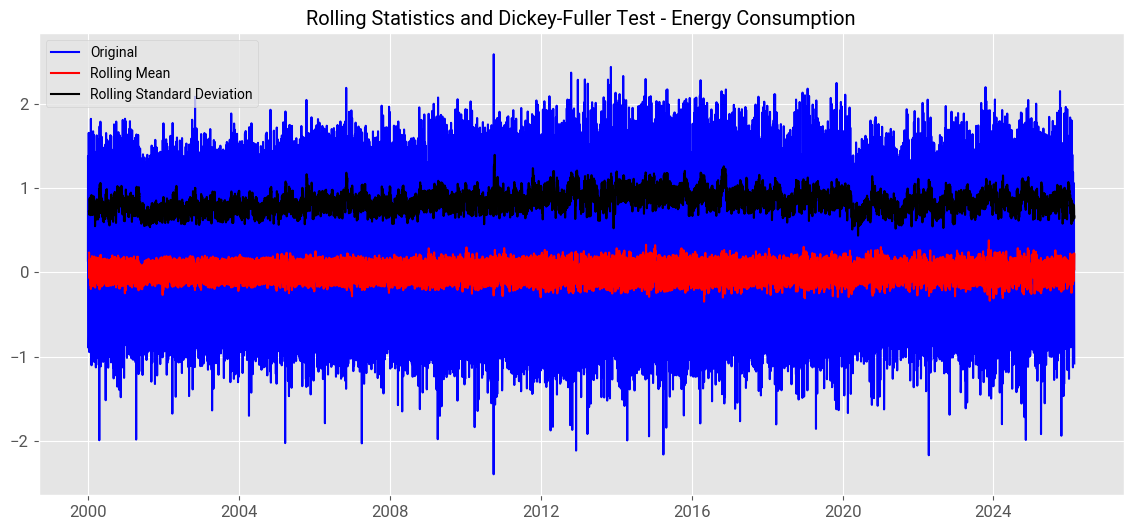


Results of Dickey-Fuller Test:
Test Statistic                  -20.904989
p-value                           0.000000
Number of Lags Used              38.000000
Number of Observations Used    9509.000000
Critical Value (1%)              -3.431038
Critical Value (5%)              -2.861844
Critical Value (10%)             -2.566932
dtype: float64

Conclusion:
The p-value is less than 0.05; therefore, we have evidence to reject the null hypothesis. This series is likely stationary.



In [126]:
test_stationarity (df4_diff2, window=12, title='Rolling Statistics and Dickey-Fuller Test - Energy Consumption')

In [129]:
df4_diff2.head()

date
2000-01-02    0.139074
2000-01-03    1.378525
2000-01-04    0.415535
2000-01-05    0.202780
2000-01-06    0.182200
Name: consumption_mwh_day, dtype: float64